# Analysis of cognitive trajectories using Linear Mixed Models (LMM)

This notebook investigates the influence of various factors on cognitive development (MMSE) over time. We use Mixed Models to account for the individual variability of the participants.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Design settings
sns.set_theme(style="whitegrid")

In [2]:
# Configuration & renaming for better readability
rename_map = {
    'NACCNE4S': 'APOE4_Status',
    'EDUC': 'Education',
    'CDRSUM': 'CDR_Sum',
    'ANIMALS': 'Word_Fluency',
    'DEP2YRS': 'Depression_2Years',
    'NACCGDS': 'Depression_Scale',
    'APA': 'Apathy',
    #'APASEV': 'Apathy_Severity',   # Excluded due to high sparsity (~18% valid)
    #'ANXIETY': 'Anxiety_Disorder', # Excluded due to extreme sparsity (~7% valid)
    'B12DEF': 'B12_Deficiency',
    'DIABETES': 'Diabetes',
    'HYPERTEN': 'Hypertension',
    'NACCBMI': 'BMI',
    'TOBAC100': 'Smoking_Status',
    'NACCLIVS': 'Living_Situation'
}

# List of readable feature names (excluding commented out ones)
readable_features = [v for k, v in rename_map.items() if not k.startswith('#')]


In [3]:
# Load data
df_raw = pd.read_csv('../data/investigator_nacc72.csv', low_memory=False)
df_groups = pd.read_csv('../data/data_with_groups.csv')

# Merge via NACCID
df = pd.merge(df_raw, df_groups[['NACCID', 'Group']], on='NACCID', how='inner')

# Rename columns
df = df.rename(columns=rename_map)

In [4]:
# Preprocessing

# Clean NACCMMSE (0-30)
df['NACCMMSE'] = pd.to_numeric(df['NACCMMSE'], errors='coerce')
df = df[(df['NACCMMSE'] >= 0) & (df['NACCMMSE'] <= 30)].copy()

# Create years since baseline from NACCDAYS
df['Years_since_Baseline'] = df['NACCDAYS'] / 365.25

# Clean features: replace NACC specific codes for unknown/not-applicable with NaN
for col in readable_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Typical NACC codes for unknown are 9, 99, 8, 88, -4
    df.loc[df[col].isin([9, 99, 8, 88, -4]), col] = np.nan

# Drop rows with NaN in critical features to maintain sample size and accuracy
cols_to_use = ['NACCMMSE', 'Years_since_Baseline'] + readable_features
df = df.dropna(subset=cols_to_use).copy()

# Only include participants with at least 2 visits (useful for trajectory analysis)
counts = df.groupby('NACCID').size()
ids_with_history = counts[counts >= 2].index
df = df[df['NACCID'].isin(ids_with_history)].copy()


In [5]:
# Dynamic model creation

# Assemble formula: NACCMMSE ~ Years_since_Baseline * (F1 + F2 + ...)
# We wrap variable names in backticks if they contain special characters
formula_vars = " + ".join(f"Q('{var}')" for var in readable_features)
formula = f"NACCMMSE ~ Years_since_Baseline * ({formula_vars})"

# Calculate Linear Mixed Model (LMM)
# NACCID serves as grouping variable for random intercepts
model = smf.mixedlm(formula, data=df, groups=df["NACCID"])
result = model.fit()


In [6]:
# Summary of results
print(result.summary())

# Interpretation:
# A positive coefficient for an interaction (e.g., Years_since_Baseline:Education)
# indicates a protective influence. This means that this factor 
# slows down cognitive decline or even promotes stabilization.

                         Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           NACCMMSE    
No. Observations:           58231             Method:                       REML        
No. Groups:                 14896             Scale:                        2.5925      
Min. group size:            2                 Log-Likelihood:               -123608.3494
Max. group size:            10                Converged:                    Yes         
Mean group size:            3.9                                                         
----------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z     P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                   26.431    0.180  146.567 0.000 26.077 26.784
Years_since_Baseline                         0.

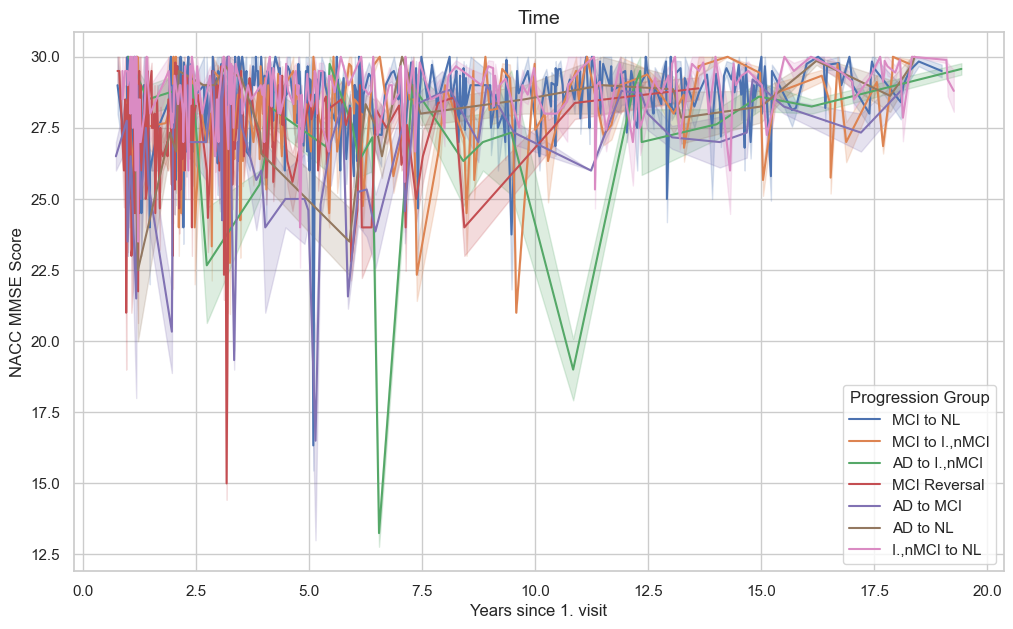

In [7]:
# Viz of MMSE

# Selection of relevant groups for comparison
focus_groups = ['AD to MCI', 'MCI to I.,nMCI', 'I.,nMCI to NL', 'MCI to NL', 'AD to I.,nMCI', 'AD to NL', 'MCI Reversal']
df_viz = df[df["Group"].isin(focus_groups)]

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_viz, x="Years_since_Baseline", y="NACCMMSE", hue="Group", errorbar=("se", 1))

plt.title("Time", fontsize=14)
plt.xlabel("Years since 1. visit", fontsize=12)
plt.ylabel("NACC MMSE Score", fontsize=12)
plt.legend(title="Progression Group")
plt.show()